# 高校数学とJulia言語 Day 4

- 城北中学校・高等学校　中学3年・高校1年
- 夏期講習会III 2026/8/24~2026/8/28
- 担当：清水団

## 本日のテーマ:関数のグラフを描いて最大・最小を求めよう!

### 今年のテーマ「実験する高校数学」

- 整数は**探す**・場合の数は**全部作る**・関数は**描く**・確率は**試す**

### 5日間の学習予定

- **Day 1**：Google Colabの紹介・Juliaで計算しよう ✅
- **Day 2**：整数問題をプログラムで考えよう ✅
- **Day 3**：場合の数・組合せを実験しよう ✅
- **Day 4**：関数・グラフ・最大最小 ← 今日
- **Day 5**：確率・シミュレーション


## 今日のテーマ：「描く」

数式は、描いてみるとその「性格」が一目で分かります。

- 関数を定義する（数学とほぼ同じ書き方!）
- グラフを描く・重ねる・動かす
- グラフと数値実験で最大・最小を探す

最大・最小は実生活でも大活躍：利益の最大化、材料の最小化、最高記録を出す軌道……

## 必要なパッケージの準備

グラフの描画に必要なパッケージを読み込みましょう。（初回だけ時間がかかります）

In [1]:
# パッケージの読み込み
# フォント設定（日本語ラベルのため）
using Pkg
Pkg.add(url="https://github.com/ujimushi/PlotsGRBackendFontJaEmoji.jl")
using PlotsGRBackendFontJaEmoji, Plots
gr()

println("パッケージの読み込み完了!")

    Updating git-repo `https://github.com/ujimushi/PlotsGRBackendFontJaEmoji.jl`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


パッケージの読み込み完了!


## Julia言語での関数の定義

### 1. 基本的な関数定義

```julia
function 関数名(引数)
    # 処理
    return 戻り値
end
```

### 2. 短縮形での関数定義（おすすめ）

```julia
関数名(引数) = 式
```

数学の $f(x) = 2x + 1$ が、そのまま `f(x) = 2x + 1` と書けます!

In [2]:
# 1次関数
f(x) = 2x + 1

f (generic function with 1 method)

In [3]:
# 関数の値を求めてみよう
f(3)

7

In [4]:
# 2次関数
g(x) = x^2 - 3x + 2

g (generic function with 1 method)

In [5]:
# g(1) と g(0) を求めてみよう
g(1), g(0)

(0, 2)

## グラフを描いてみよう!

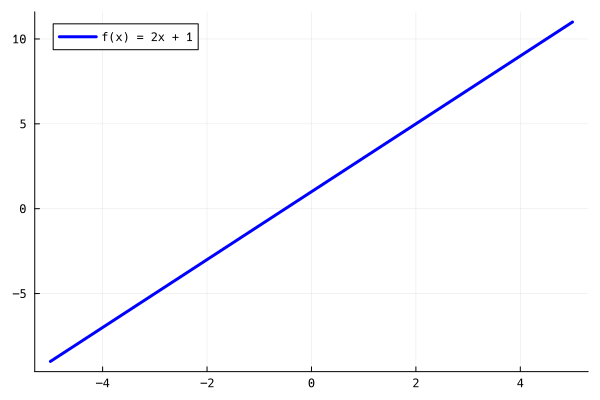

In [6]:
# 1次関数のグラフ
plot(f, lw=3, color=:blue, label="f(x) = 2x + 1")

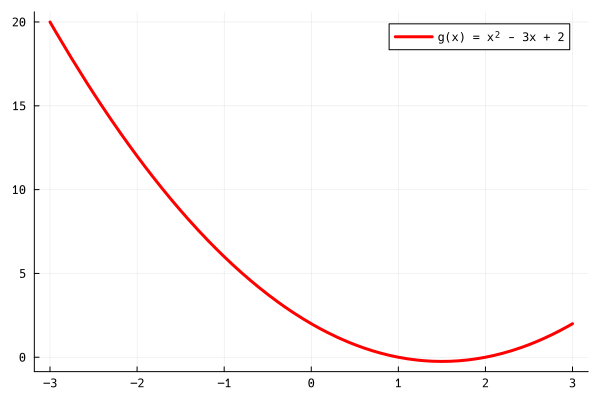

In [7]:
# 範囲を指定して描く（-3 ≤ x ≤ 3）
plot(g, -3, 3, lw=3, color=:red, label="g(x) = x² - 3x + 2")

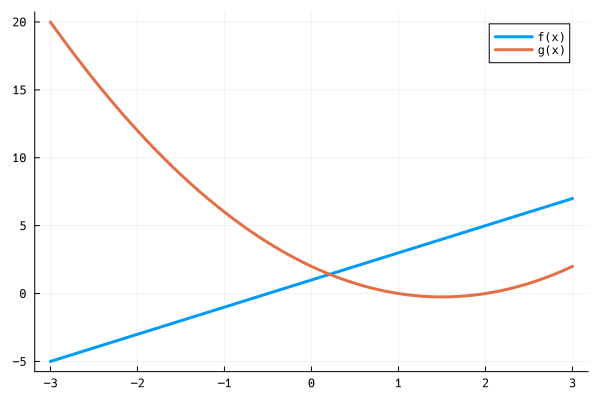

In [8]:
# 2つのグラフを重ねる（plot! の ! は「上書き」の意味）
plot(f, -3, 3, lw=3, label="f(x)")
plot!(g, -3, 3, lw=3, label="g(x)")

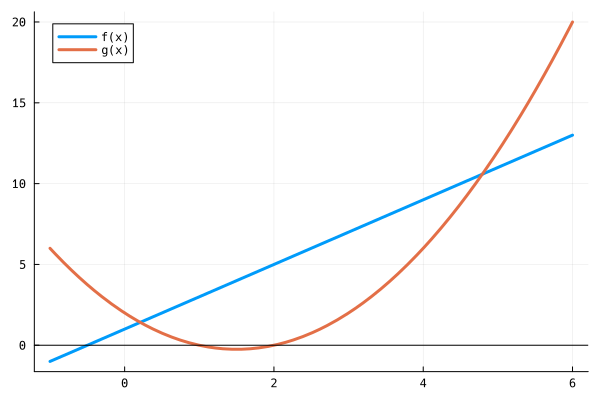

In [9]:
# 交点のあたりを拡大してみよう
plot(f, -1, 6, lw=3, label="f(x)")
plot!(g, -1, 6, lw=3, label="g(x)")
hline!([0], color=:black, label="")  # x軸

### 実験:交点を数値で探す

$f(x) = g(x)$、つまり $2x+1 = x^2-3x+2$ の解を実験で探してみましょう。

In [10]:
# 差の関数が0になるところが交点
h(x) = g(x) - f(x)
# 符号が変わる場所を探す
for x in -1:0.5:6
    println("x = $x: h(x) = $(h(x))")
end

x = -1.0: h(x) = 7.0
x = -0.5: h(x) = 3.75
x = 0.0: h(x) = 1.0
x = 0.5: h(x) = -1.25
x = 1.0: h(x) = -3.0
x = 1.5: h(x) = -4.25
x = 2.0: h(x) = -5.0
x = 2.5: h(x) = -5.25
x = 3.0: h(x) = -5.0
x = 3.5: h(x) = -4.25
x = 4.0: h(x) = -3.0
x = 4.5: h(x) = -1.25
x = 5.0: h(x) = 1.0
x = 5.5: h(x) = 3.75
x = 6.0: h(x) = 7.0


In [11]:
# 解の公式で確認: x² - 5x + 1 = 0
(5 + sqrt(21))/2, (5 - sqrt(21))/2

(4.7912878474779195, 0.20871215252208009)

## パラメータを動かして実験しよう

$y = x^2 + bx$ の $b$ をいろいろ変えると、グラフはどう動くでしょう?

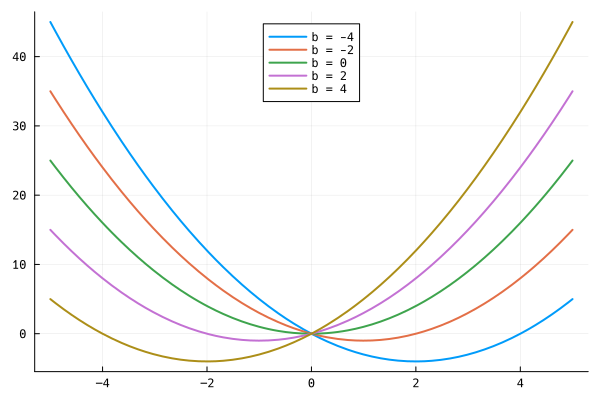

In [12]:
# bを変えて重ねて描く
p = plot(legend=:top)
for b in -4:2:4
    plot!(p, x -> x^2 + b*x, -5, 5, lw=2, label="b = $b")
end
p

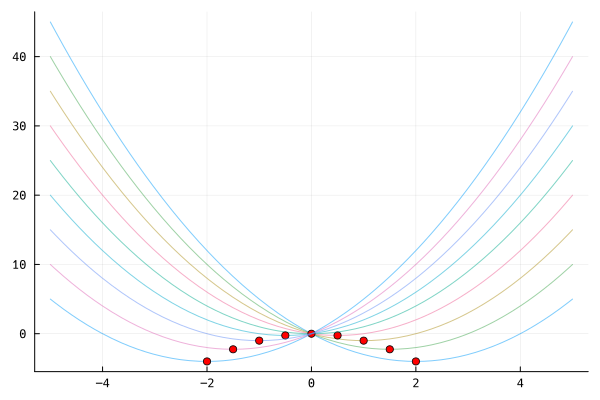

In [13]:
# 頂点だけを追いかけると?（頂点は x = -b/2）
p = plot(legend=:top)
for b in -4:1:4
    plot!(p, x -> x^2 + b*x, -5, 5, lw=1, alpha=0.5, label="")
    scatter!(p, [-b/2], [(-b/2)^2 + b*(-b/2)], color=:red, label="")
end
p

頂点は放物線 $y = -x^2$ の上を動いています! これも「実験」から見つかる事実です。

## 最大・最小を求めよう

### 問題1:2次関数 $f(x) = -x^2 + 4x + 1$ の最大値を求める

まずグラフを描いて、最大値がどのあたりか**目で**確認しましょう。

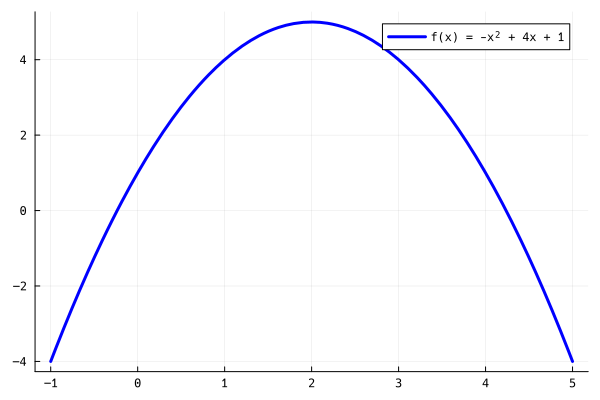

In [14]:
# 関数を定義してグラフを描く
f1(x) = -x^2 + 4x + 1
plot(f1, -1, 5, lw=3, color=:blue, label="f(x) = -x² + 4x + 1")

In [15]:
# 数値実験:xを細かく動かして最大値を探す
xs = -1:0.001:5
ys = f1.(xs)          # .（ドット）で全部に適用
maximum(ys)

5.0

In [16]:
# 最大になるときの x は?
xs[argmax(ys)]

2.0

実験結果:$x = 2$ のとき最大値 $5$。

平方完成 $f(x) = -(x-2)^2 + 5$ と一致します!

### 問題2:定義域に制限がある場合

$f(x) = x^2 - 4x + 3$（$0 \le x \le 3$）の最大値・最小値は?

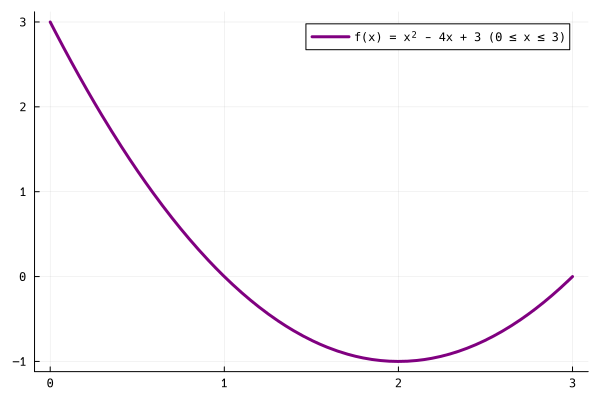

In [17]:
# グラフで確認（定義域を0〜3に）
f2(x) = x^2 - 4x + 3
plot(f2, 0, 3, lw=3, color=:purple, label="f(x) = x² - 4x + 3 (0 ≤ x ≤ 3)")

In [18]:
# 数値実験
xs = 0:0.001:3
ys = f2.(xs)
println("最大値: $(maximum(ys)) （x = $(xs[argmax(ys)])）")
println("最小値: $(minimum(ys)) （x = $(xs[argmin(ys)])）")

最大値: 3.0 （x = 0.0）
最小値: -1.0 （x = 2.0）


端点 $x=0$ で最大値 $3$、頂点 $x=2$ で最小値 $-1$。

**定義域の端と頂点**に注目するのがポイントでしたね。グラフを見れば一目瞭然です。

### 問題3:3次関数にも挑戦!

$f(x) = x^3 - 3x$ のグラフはどんな形?（高校2年生で学ぶ「極値」を先取り!）

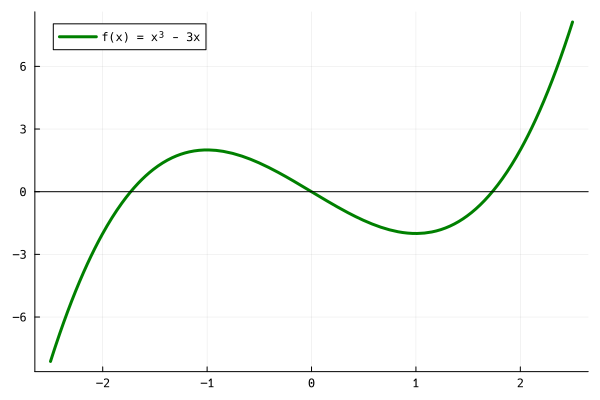

In [19]:
# 3次関数のグラフ
f3(x) = x^3 - 3x
plot(f3, -2.5, 2.5, lw=3, color=:green, label="f(x) = x³ - 3x")
hline!([0], color=:black, label="")

In [20]:
# 山の頂上（極大）と谷の底（極小）を数値実験で探す
xs = -2:0.001:0
println("極大: $(maximum(f3.(xs))) （x = $(xs[argmax(f3.(xs))])）")
xs = 0:0.001:2
println("極小: $(minimum(f3.(xs))) （x = $(xs[argmin(f3.(xs))])）")

極大: 2.0 （x = -1.0）
極小: -2.0 （x = 1.0）


## 応用問題:文章題を「描いて」解く

**問題**:長さ20mのロープで長方形の囲いを作る。面積を最大にするには縦の長さをいくらにすればよい?

縦を $x$ とすると横は $10 - x$ なので、面積は $S(x) = x(10 - x)$（$0 < x < 10$）

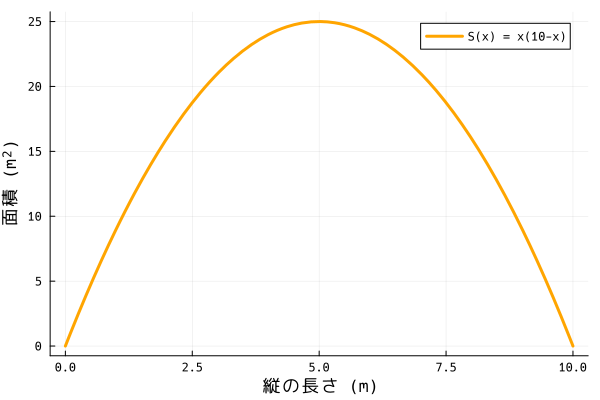

In [21]:
# 面積の関数を描く
S(x) = x * (10 - x)
plot(S, 0, 10, lw=3, color=:orange, label="S(x) = x(10-x)", xlabel="縦の長さ (m)", ylabel="面積 (m²)")

In [22]:
# 数値実験で最大値を探す
xs = 0:0.001:10
println("最大面積: $(maximum(S.(xs))) m² （縦 = $(xs[argmax(S.(xs))]) m）")

最大面積: 25.0 m² （縦 = 5.0 m）


縦 $5$m（=正方形）のとき最大面積 $25$m²。

「周の長さが一定の長方形では正方形が最大」——グラフが教えてくれました。

## Day 4 の演習問題

- まずグラフを描いて予想 → 数値実験 → 手計算で確認しよう
- ノートブックを保存して、Google Classroomから提出しよう

### 問題1: グラフを描こう

$f(x) = x^2 - 6x + 7$ のグラフを描き、頂点の座標をグラフから読み取ろう。
その後、数値実験で最小値を確かめよう。

### 問題2: 定義域つきの最大・最小

$f(x) = -x^2 + 2x + 3$（$0 \le x \le 4$）の最大値と最小値を、グラフと数値実験で求めよう。

### 問題3: 文章題

長さ40cmの針金を折り曲げて長方形を作る。面積が最大になるときの縦の長さと最大面積を、
関数のグラフを描いて求めよう。

### 問題4: チャレンジ問題

$f(x) = x + \dfrac{4}{x}$（$x > 0$）の最小値を数値実験で探そう。
（相加平均・相乗平均の関係 $x + \frac{4}{x} \ge 2\sqrt{4} = 4$ の「実験版」です!）

## 解答欄

以下のセルに解答を記入してください。

### 問題1の解答

In [23]:
# グラフを描く



In [24]:
# 数値実験で最小値



### 問題2の解答

In [25]:
# グラフと数値実験



### 問題3の解答

In [26]:
# 面積の関数を定義して描く



### 問題4の解答

In [27]:
# x + 4/x の最小値



## Day 4 まとめ

今日学習した内容

- **関数定義**:`f(x) = 2x + 1` —— 数学そのままの記法
- **グラフ描画**:`plot`, `plot!`, 範囲指定, パラメータ実験
- **最大・最小**:グラフで予想 → `maximum`/`argmax` で数値実験
- **応用**:文章題も「関数を作って描けば」解ける

グラフは関数の「顔」。描けば増減・頂点・対称性がすべて見えます。

明日は最終日、**確率**。サイコロを1万回「試して」、理論と実験の一致を見届けましょう!